In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [99]:
df=pd.read_csv('E:\Project2-LaptopPricePrediction\laptop_data (1).csv')

In [100]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


# preprocessing starts!!!

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [102]:
df.shape

(1303, 12)

In [103]:
df.duplicated().sum()

np.int64(0)

In [104]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

# Data cleaning #

In [105]:
df=df.drop(columns=['Unnamed: 0'],axis=1)

In [106]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [107]:
df['Ram']=df['Ram'].str.replace('GB','')
df['Ram']=df['Ram'].astype('int32')
df['Weight']=df['Weight'].str.replace('kg','')
df['Weight']=df['Weight'].astype('float')

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
dtypes: float64(3), int32(1), object(7)
memory usage: 107.0+ KB


# EDA

C:\Users\User\AppData\Local\Temp\ipykernel_26536\834922981.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


<Axes: xlabel='Price', ylabel='Density'>

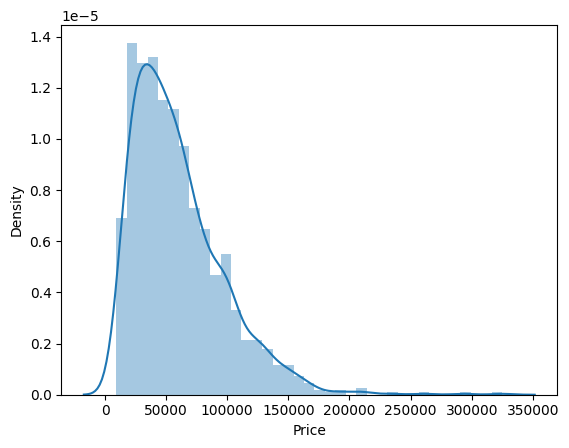

In [109]:
sns.distplot(df['Price'])

In [110]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64

<Axes: xlabel='Company'>

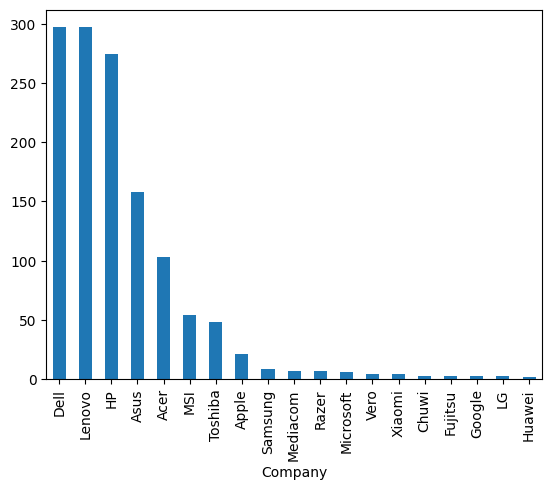

In [111]:
df['Company'].value_counts().plot(kind='bar')

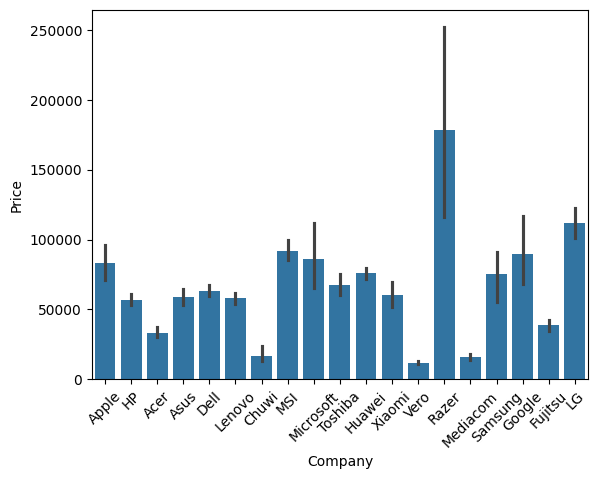

In [112]:
#Price based on company
sns.barplot(x=df['Company'],y=df['Price'])
plt.xticks(rotation=45)
plt.show()

In [113]:
df['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

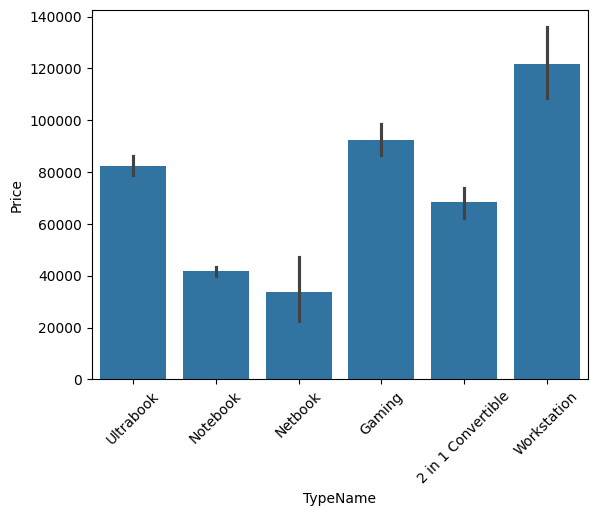

In [114]:
#laptop price based on laptop type
sns.barplot(x=df['TypeName'],y=df['Price'])
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Inches', ylabel='Price'>

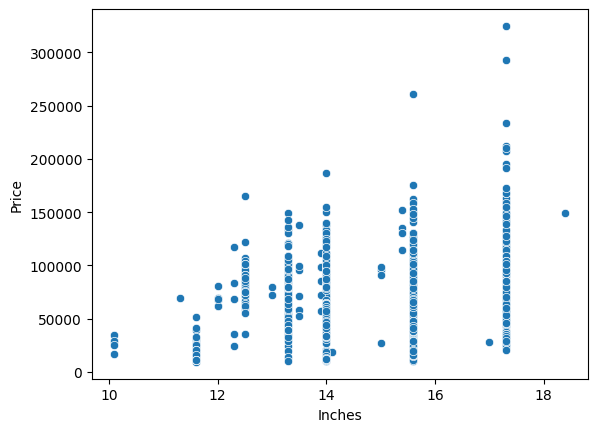

In [115]:
#relationshsip between price and size
sns.scatterplot(x=df['Inches'],y=df['Price'])

# Feature Engineering

In [116]:
df['ScreenResolution'].nunique()

40

In [117]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [118]:
#Finding out and creating a columnn from 'screenresolution' column, touchscreen or not?
df['TouchScreen']=df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0


<Axes: xlabel='TouchScreen'>

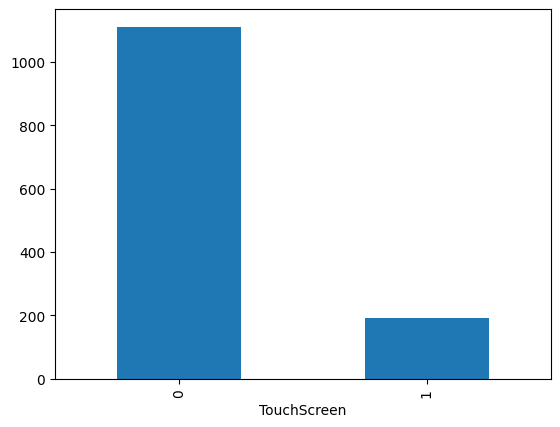

In [119]:

df['TouchScreen'].value_counts().plot(kind='bar')

<Axes: xlabel='TouchScreen', ylabel='Price'>

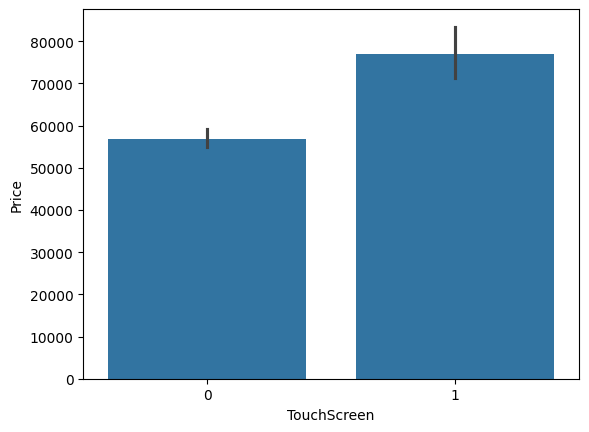

In [120]:
sns.barplot(x=df['TouchScreen'],y=df['Price'])


In [121]:
#Finding out and creating a columnn from 'screenresolution' column, touchscreen or not?
df['IPS']=df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1


<Axes: xlabel='IPS'>

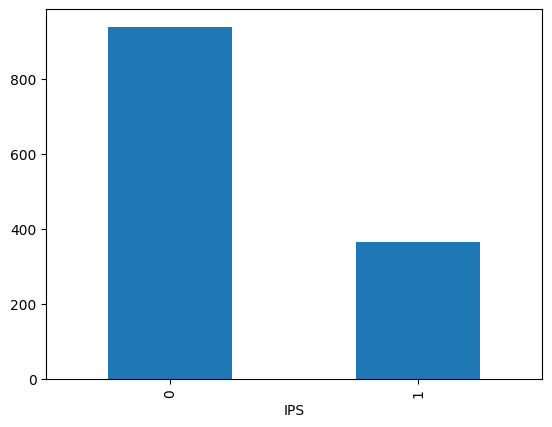

In [122]:
df['IPS'].value_counts().plot(kind='bar')

<Axes: xlabel='IPS', ylabel='Price'>

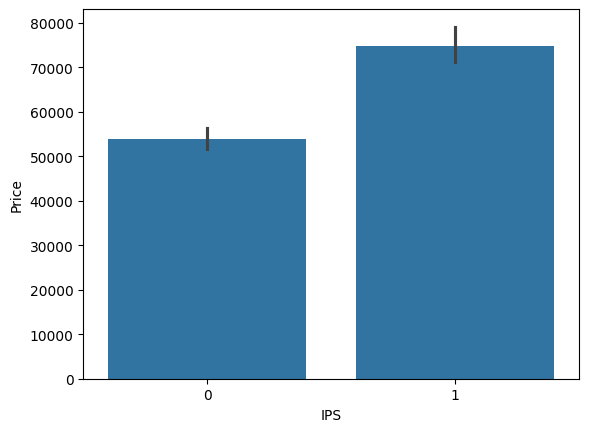

In [123]:
sns.barplot(x=df['IPS'],y=df['Price'])

In [124]:
df.sample(3)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
1059,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.94,96916.32,0,0
719,HP,Notebook,17.3,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Nvidia GeForce 930MX,Windows 10,2.63,63936.00,0,0
716,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7300U 2.6GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.90,62817.12,0,0


In [125]:
new=df['ScreenResolution'].str.split('x',expand=True)
new

,0,1
0,IPS Panel Retina Display 2560,1600
1,1440,900
2,Full HD 1920,1080
3,IPS Panel Retina Display 2880,1800
4,IPS Panel Retina Display 2560,1600
...,...,...
1298,IPS Panel Full HD / Touchscreen 1920,1080
1299,IPS Panel Quad HD+ / Touchscreen 3200,1800
1300,1366,768
1301,1366,768


In [126]:
df['x_res']=new[0]
df['y_res']=new[1]

In [127]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,Full HD 1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,IPS Panel Retina Display 2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,IPS Panel Retina Display 2560,1600


In [128]:
df['x_res']=df['x_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

In [129]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  TouchScreen       1303 non-null   int64  
 12  IPS               1303 non-null   int64  
 13  x_res             1303 non-null   object 
 14  y_res             1303 non-null   object 
dtypes: float64(3), int32(1), int64(2), object(9)
memory usage: 147.7+ KB


In [131]:
df['x_res']=df['x_res'].astype('int32')
df['y_res']=df['y_res'].astype('int32')

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  TouchScreen       1303 non-null   int64  
 12  IPS               1303 non-null   int64  
 13  x_res             1303 non-null   int32  
 14  y_res             1303 non-null   int32  
dtypes: float64(3), int32(3), int64(2), object(7)
memory usage: 137.6+ KB


In [133]:
df.drop(columns=['ScreenResolution'])

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,1920,1080
1299,Lenovo,2 in 1 Convertible,13.3,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,3200,1800
1300,Lenovo,Notebook,14.0,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,1366,768
1301,HP,Notebook,15.6,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,1366,768


In [134]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [135]:
df['Cpu'].nunique()

118

In [136]:
df['cpu_name']=df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

In [137]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_name
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5


In [138]:
def fetch_cputype(type):
    if type=='Intel Core i5' or type=='Intel Core i7' or type=='Intel Core i3':
        return type
    else:
        if type.split()[0]=='Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD processor'

In [139]:
df['cpu_type']=df['cpu_name'].apply(fetch_cputype)

In [140]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_name,cpu_type
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5,Intel Core i5
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5,Intel Core i5


<Axes: xlabel='cpu_type'>

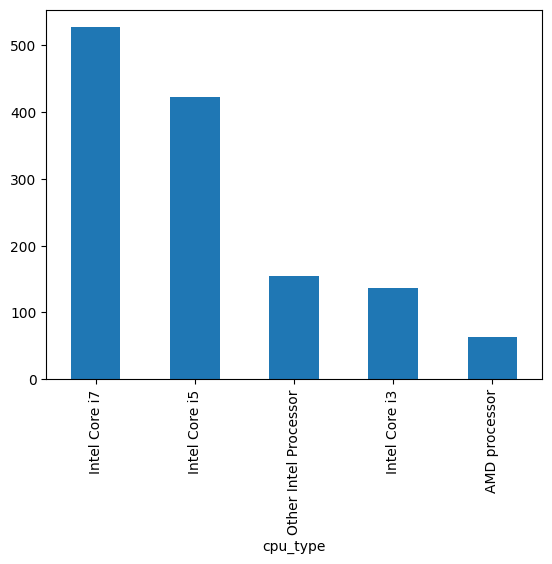

In [141]:
df['cpu_type'].value_counts().plot(kind='bar')

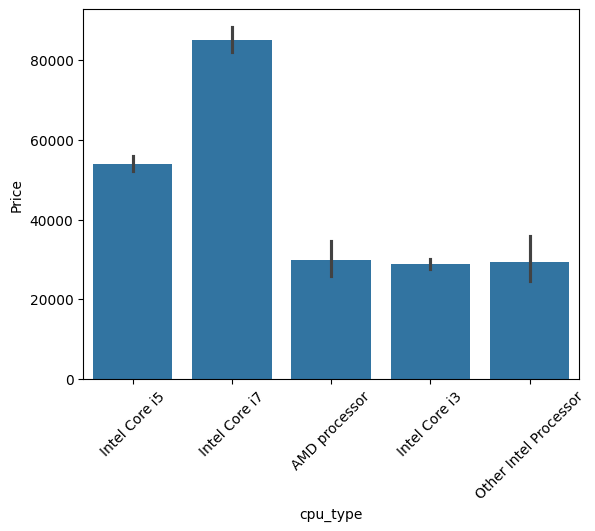

In [142]:
sns.barplot(x=df['cpu_type'],y=df['Price'])
plt.xticks(rotation=45)
plt.show()

In [143]:
df.drop(columns=['Cpu','cpu_name','ScreenResolution'],inplace=True)

In [144]:
df.head()

,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_type
0,Apple,Ultrabook,13.3,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5
1,Apple,Ultrabook,13.3,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5
2,HP,Notebook,15.6,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5
3,Apple,Ultrabook,15.4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7
4,Apple,Ultrabook,13.3,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5


<Axes: xlabel='Ram'>

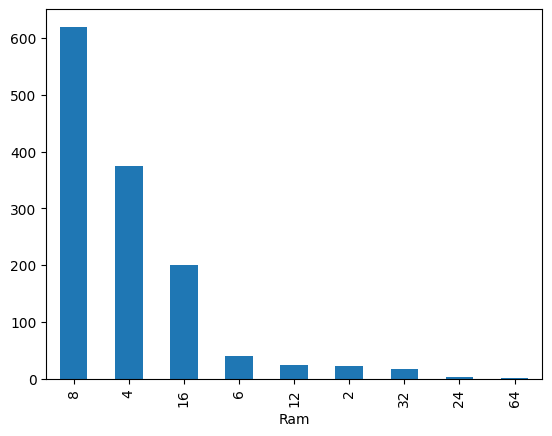

In [145]:
df['Ram'].value_counts().plot(kind='bar')

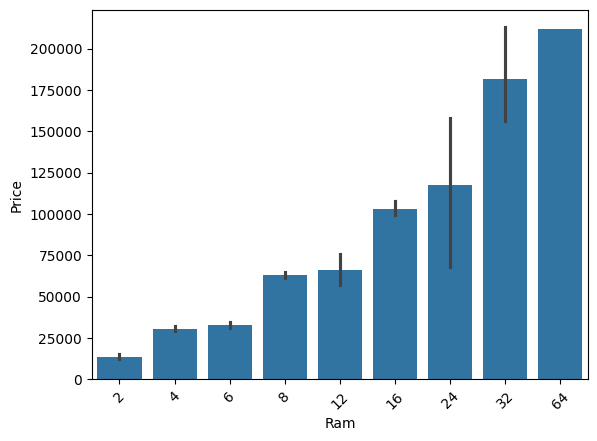

In [146]:
sns.barplot(x=df['Ram'],y=df['Price'])
plt.xticks(rotation=45)
plt.show()

In [147]:
df.head()

,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_type
0,Apple,Ultrabook,13.3,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5
1,Apple,Ultrabook,13.3,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5
2,HP,Notebook,15.6,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5
3,Apple,Ultrabook,15.4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7
4,Apple,Ultrabook,13.3,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1303 non-null   object 
 1   TypeName     1303 non-null   object 
 2   Inches       1303 non-null   float64
 3   Ram          1303 non-null   int32  
 4   Memory       1303 non-null   object 
 5   Gpu          1303 non-null   object 
 6   OpSys        1303 non-null   object 
 7   Weight       1303 non-null   float64
 8   Price        1303 non-null   float64
 9   TouchScreen  1303 non-null   int64  
 10  IPS          1303 non-null   int64  
 11  x_res        1303 non-null   int32  
 12  y_res        1303 non-null   int32  
 13  cpu_type     1303 non-null   object 
dtypes: float64(3), int32(3), int64(2), object(6)
memory usage: 127.4+ KB


In [149]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [150]:
df['Memory']=df['Memory'].astype(str)
df['Memory']=df['Memory'].replace(r'\.0','',regex=True)
df['Memory']=df['Memory'].replace('GB','')
df['Memory']=df['Memory'].replace('TB','000')
new=df['Memory'].str.split("+",n=1,expand=True)

df["first"]= new[0]
df["first"]=df["first"].str.strip()
df["second"]= new[1]
df['second'].value_counts()

second
1TB HDD       185
2TB HDD        15
256GB SSD       3
500GB HDD       2
1TB Hybrid      2
512GB SSD       1
Name: count, dtype: int64

In [151]:
df['first'].value_counts()

first
256GB SSD              500
1TB HDD                225
128GB SSD              172
512GB SSD              138
500GB HDD              132
32GB Flash Storage      38
64GB Flash Storage      16
2TB HDD                 16
1TB SSD                 16
1TB Hybrid               9
256GB Flash Storage      8
16GB Flash Storage       7
32GB SSD                 6
180GB SSD                5
128GB Flash Storage      4
16GB SSD                 3
512GB Flash Storage      2
64GB SSD                 1
32GB HDD                 1
128GB HDD                1
240GB SSD                1
8GB SSD                  1
508GB Hybrid             1
Name: count, dtype: int64

In [152]:
df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['first'] = df['first'].str.replace(r'\D', '')
df["second"].fillna("0", inplace = True)
df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_26536\4166229309.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["second"].fillna("0", inplace = True)


,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_type,first,second,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1Flash_Storage
0,Apple,Ultrabook,13.3,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5,128GB SSD,0,0,1,0,0
1,Apple,Ultrabook,13.3,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5,128GB Flash Storage,0,0,0,0,1
2,HP,Notebook,15.6,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5,256GB SSD,0,0,1,0,0
3,Apple,Ultrabook,15.4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7,512GB SSD,0,0,1,0,0
4,Apple,Ultrabook,13.3,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5,256GB SSD,0,0,1,0,0


In [153]:
df["second"] = df["second"].astype(str)
df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)
df["second"] = df["second"].str.replace(r"\D", "", regex=True)
df["second"] = df["second"].replace("", "0").astype(int)


In [154]:
df[['first','second','Layer1HDD','Layer2HDD']].dtypes


first        object
second        int64
Layer1HDD     int64
Layer2HDD     int64
dtype: object

In [155]:
num_cols = [
    'first','second',
    'Layer1HDD','Layer1SSD','Layer1Hybrid','Layer1Flash_Storage',
    'Layer2HDD','Layer2SSD','Layer2Hybrid','Layer2Flash_Storage'
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)


In [156]:
df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [157]:
df.head()

,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,13.3,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5,0.0,0.0,0.0,0.0
1,Apple,Ultrabook,13.3,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5,0.0,0.0,0.0,0.0
2,HP,Notebook,15.6,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5,0.0,0.0,0.0,0.0
3,Apple,Ultrabook,15.4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7,0.0,0.0,0.0,0.0
4,Apple,Ultrabook,13.3,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5,0.0,0.0,0.0,0.0


In [158]:
df.drop(columns=['Memory'],inplace=True)


In [159]:
df.head()

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5,0.0,0.0,0.0,0.0
1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5,0.0,0.0,0.0,0.0
2,HP,Notebook,15.6,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5,0.0,0.0,0.0,0.0
3,Apple,Ultrabook,15.4,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7,0.0,0.0,0.0,0.0
4,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5,0.0,0.0,0.0,0.0


In [160]:
 df.select_dtypes(include='number').corr()['Price']


Inches           0.068197
Ram              0.743007
Weight           0.210370
Price            1.000000
TouchScreen      0.191226
IPS              0.252208
x_res            0.556529
y_res            0.552809
HDD              0.026773
SSD              0.023477
Hybrid           0.105004
Flash_Storage         NaN
Name: Price, dtype: float64

In [161]:
df=df.drop(columns=['Hybrid','Flash_Storage'])

In [162]:
df

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD
0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5,0.0,0.0
1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5,0.0,0.0
2,HP,Notebook,15.6,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5,0.0,0.0
3,Apple,Ultrabook,15.4,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7,0.0,0.0
4,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,4,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,1920,1080,Intel Core i7,0.0,0.0
1299,Lenovo,2 in 1 Convertible,13.3,16,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,3200,1800,Intel Core i7,0.0,0.0
1300,Lenovo,Notebook,14.0,2,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,1366,768,Other Intel Processor,0.0,0.0
1301,HP,Notebook,15.6,6,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,1366,768,Intel Core i7,0.0,0.0


In [163]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [164]:
df['Gpu']=df['Gpu'].apply(lambda x:x.split()[0])

In [165]:
df.head()

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD
0,Apple,Ultrabook,13.3,8,Intel,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5,0.0,0.0
1,Apple,Ultrabook,13.3,8,Intel,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5,0.0,0.0
2,HP,Notebook,15.6,8,Intel,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5,0.0,0.0
3,Apple,Ultrabook,15.4,16,AMD,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7,0.0,0.0
4,Apple,Ultrabook,13.3,8,Intel,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5,0.0,0.0


In [166]:
df['Gpu'].value_counts()

Gpu
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [167]:
df=df[df['Gpu'] !='ARM']

<Axes: xlabel='Gpu'>

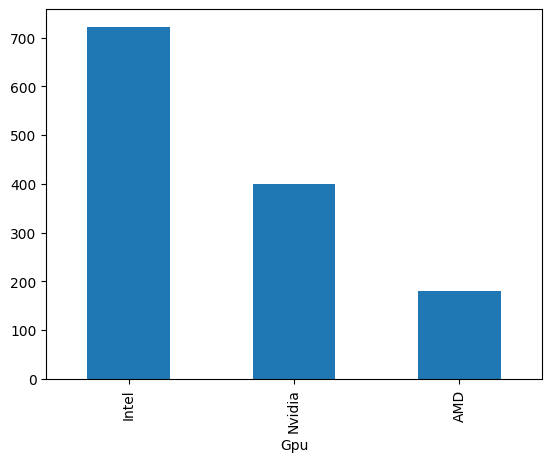

In [168]:
df['Gpu'].value_counts().plot(kind='bar')

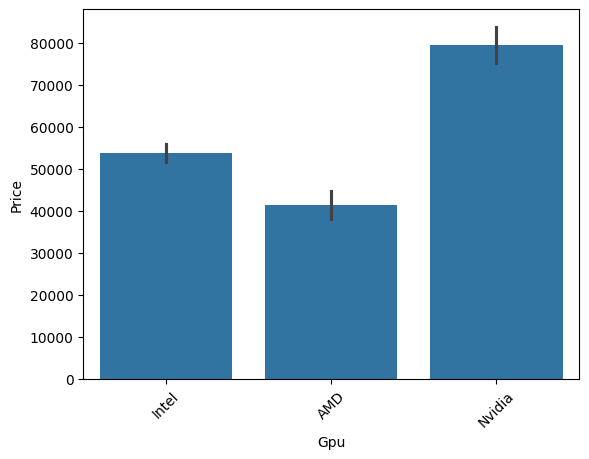

In [169]:
sns.barplot(x=df['Gpu'],y=df['Price'])
plt.xticks(rotation=45)
plt.show()

In [170]:
df

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD
0,Apple,Ultrabook,13.3,8,Intel,macOS,1.37,71378.6832,0,1,2560,1600,Intel Core i5,0.0,0.0
1,Apple,Ultrabook,13.3,8,Intel,macOS,1.34,47895.5232,0,0,1440,900,Intel Core i5,0.0,0.0
2,HP,Notebook,15.6,8,Intel,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5,0.0,0.0
3,Apple,Ultrabook,15.4,16,AMD,macOS,1.83,135195.3360,0,1,2880,1800,Intel Core i7,0.0,0.0
4,Apple,Ultrabook,13.3,8,Intel,macOS,1.37,96095.8080,0,1,2560,1600,Intel Core i5,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,4,Intel,Windows 10,1.80,33992.6400,1,1,1920,1080,Intel Core i7,0.0,0.0
1299,Lenovo,2 in 1 Convertible,13.3,16,Intel,Windows 10,1.30,79866.7200,1,1,3200,1800,Intel Core i7,0.0,0.0
1300,Lenovo,Notebook,14.0,2,Intel,Windows 10,1.50,12201.1200,0,0,1366,768,Other Intel Processor,0.0,0.0
1301,HP,Notebook,15.6,6,AMD,Windows 10,2.19,40705.9200,0,0,1366,768,Intel Core i7,0.0,0.0


In [171]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

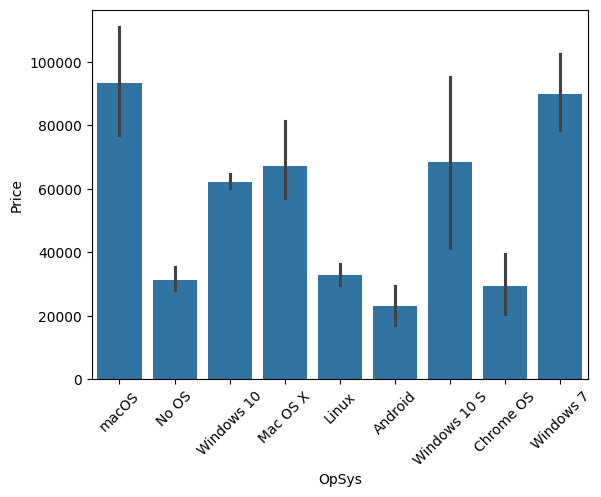

In [172]:
sns.barplot(x=df['OpSys'],y=df['Price'])
plt.xticks(rotation=45)
plt.show()

In [173]:
def OpSysType (type):
    if type=='Windows 10' or type=='Windows 10 S' or type=='Windows 7':
        return 'Windows'
    elif type=='macOS' or type=='Mac OS X':
        return 'Mac'
    else:
        return 'Linus/Android/No OS/Chrome OS'

In [174]:
df['OpSys']=df['OpSys'].apply(OpSysType)

C:\Users\User\AppData\Local\Temp\ipykernel_26536\857838933.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OpSys']=df['OpSys'].apply(OpSysType)


In [175]:
df

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD
0,Apple,Ultrabook,13.3,8,Intel,Mac,1.37,71378.6832,0,1,2560,1600,Intel Core i5,0.0,0.0
1,Apple,Ultrabook,13.3,8,Intel,Mac,1.34,47895.5232,0,0,1440,900,Intel Core i5,0.0,0.0
2,HP,Notebook,15.6,8,Intel,Linus/Android/No OS/Chrome OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5,0.0,0.0
3,Apple,Ultrabook,15.4,16,AMD,Mac,1.83,135195.3360,0,1,2880,1800,Intel Core i7,0.0,0.0
4,Apple,Ultrabook,13.3,8,Intel,Mac,1.37,96095.8080,0,1,2560,1600,Intel Core i5,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,4,Intel,Windows,1.80,33992.6400,1,1,1920,1080,Intel Core i7,0.0,0.0
1299,Lenovo,2 in 1 Convertible,13.3,16,Intel,Windows,1.30,79866.7200,1,1,3200,1800,Intel Core i7,0.0,0.0
1300,Lenovo,Notebook,14.0,2,Intel,Windows,1.50,12201.1200,0,0,1366,768,Other Intel Processor,0.0,0.0
1301,HP,Notebook,15.6,6,AMD,Windows,2.19,40705.9200,0,0,1366,768,Intel Core i7,0.0,0.0


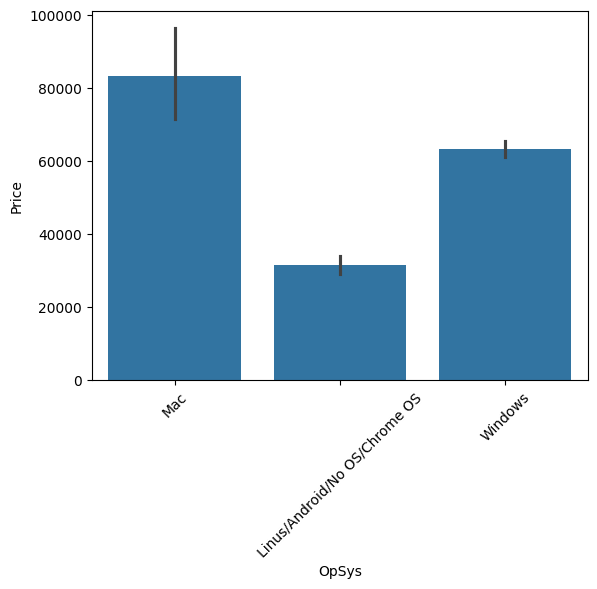

In [176]:
sns.barplot(x=df['OpSys'],y=df['Price'])
plt.xticks(rotation=45)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_26536\1125578356.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

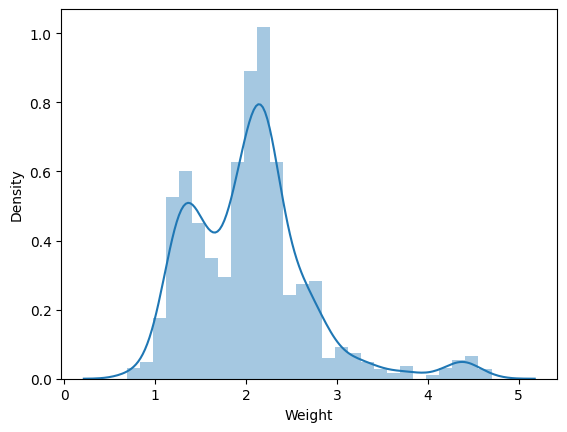

In [177]:
sns.distplot(df['Weight'])

<Axes: xlabel='Weight', ylabel='Price'>

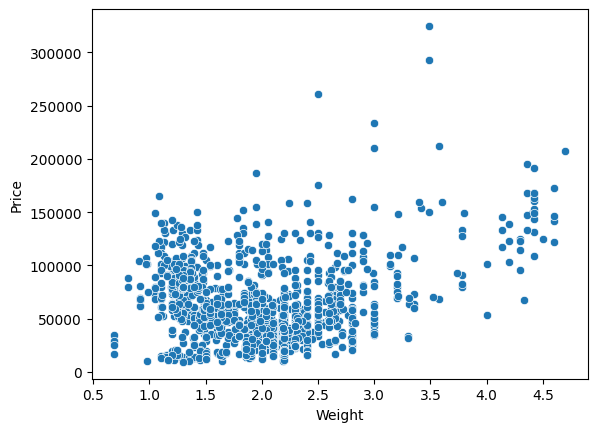

In [178]:
sns.scatterplot(x=df['Weight'],y=df['Price'])

<Axes: >

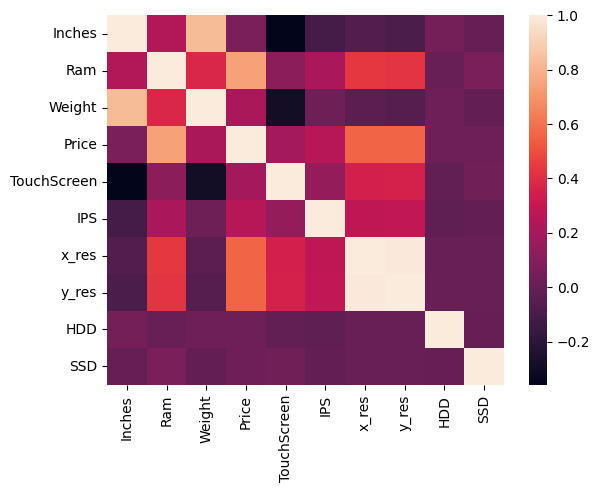

In [179]:
sns.heatmap(df.select_dtypes(include='number').corr())

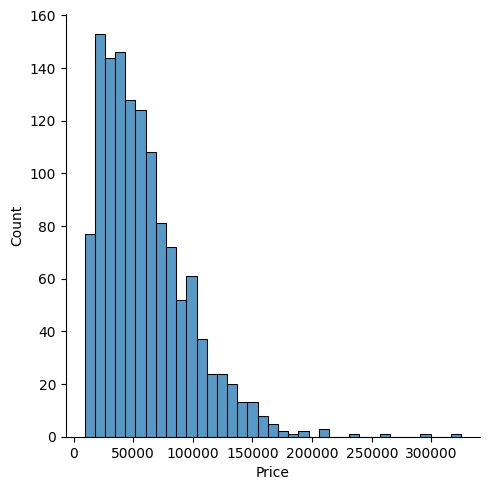

In [180]:
#transforming target col to normally distributed
sns.displot(df['Price'])

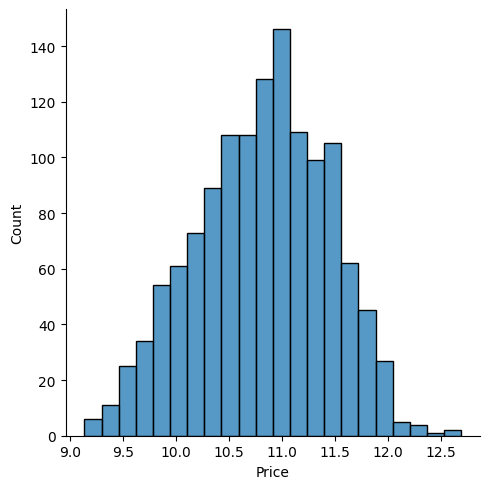

In [181]:
sns.displot(np.log(df['Price']))

### train test split ###

In [182]:
x=df.drop(columns=['Price'])
y=np.log(df['Price'])

In [183]:
x

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD
0,Apple,Ultrabook,13.3,8,Intel,Mac,1.37,0,1,2560,1600,Intel Core i5,0.0,0.0
1,Apple,Ultrabook,13.3,8,Intel,Mac,1.34,0,0,1440,900,Intel Core i5,0.0,0.0
2,HP,Notebook,15.6,8,Intel,Linus/Android/No OS/Chrome OS,1.86,0,0,1920,1080,Intel Core i5,0.0,0.0
3,Apple,Ultrabook,15.4,16,AMD,Mac,1.83,0,1,2880,1800,Intel Core i7,0.0,0.0
4,Apple,Ultrabook,13.3,8,Intel,Mac,1.37,0,1,2560,1600,Intel Core i5,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,4,Intel,Windows,1.80,1,1,1920,1080,Intel Core i7,0.0,0.0
1299,Lenovo,2 in 1 Convertible,13.3,16,Intel,Windows,1.30,1,1,3200,1800,Intel Core i7,0.0,0.0
1300,Lenovo,Notebook,14.0,2,Intel,Windows,1.50,0,0,1366,768,Other Intel Processor,0.0,0.0
1301,HP,Notebook,15.6,6,AMD,Windows,2.19,0,0,1366,768,Intel Core i7,0.0,0.0


In [184]:
y

0       11.175755
1       10.776777
2       10.329931
3       11.814476
4       11.473101
          ...    
1298    10.433899
1299    11.288115
1300     9.409283
1301    10.614129
1302     9.886358
Name: Price, Length: 1302, dtype: float64

In [185]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [186]:
x_train

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD
147,Asus,Notebook,15.6,4,Intel,Windows,2.00,0,0,1920,1080,Other Intel Processor,0.0,0.0
342,HP,Notebook,15.6,8,Nvidia,Windows,2.10,0,1,1920,1080,Intel Core i3,0.0,0.0
1003,HP,Notebook,14.0,4,Intel,Windows,1.64,0,0,1366,768,Intel Core i5,0.0,0.0
814,Dell,Notebook,15.6,8,AMD,Windows,2.18,0,0,1920,1080,Intel Core i5,0.0,0.0
344,Dell,Ultrabook,13.3,8,Intel,Windows,1.20,0,0,1920,1080,Intel Core i7,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Acer,Notebook,15.6,8,Nvidia,Windows,2.40,0,0,1920,1080,Intel Core i5,1.0,0.0
1130,HP,Notebook,15.6,8,Intel,Windows,2.04,0,0,1366,768,Intel Core i7,0.0,0.0
1295,Dell,Notebook,15.6,8,AMD,Linus/Android/No OS/Chrome OS,2.30,0,0,1366,768,Intel Core i7,0.0,0.0
860,Lenovo,Notebook,15.6,8,Intel,Windows,2.30,0,1,1920,1080,Intel Core i5,0.0,0.0


In [187]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [188]:
x_train

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD
147,Asus,Notebook,15.6,4,Intel,Windows,2.00,0,0,1920,1080,Other Intel Processor,0.0,0.0
342,HP,Notebook,15.6,8,Nvidia,Windows,2.10,0,1,1920,1080,Intel Core i3,0.0,0.0
1003,HP,Notebook,14.0,4,Intel,Windows,1.64,0,0,1366,768,Intel Core i5,0.0,0.0
814,Dell,Notebook,15.6,8,AMD,Windows,2.18,0,0,1920,1080,Intel Core i5,0.0,0.0
344,Dell,Ultrabook,13.3,8,Intel,Windows,1.20,0,0,1920,1080,Intel Core i7,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Acer,Notebook,15.6,8,Nvidia,Windows,2.40,0,0,1920,1080,Intel Core i5,1.0,0.0
1130,HP,Notebook,15.6,8,Intel,Windows,2.04,0,0,1366,768,Intel Core i7,0.0,0.0
1295,Dell,Notebook,15.6,8,AMD,Linus/Android/No OS/Chrome OS,2.30,0,0,1366,768,Intel Core i7,0.0,0.0
860,Lenovo,Notebook,15.6,8,Intel,Windows,2.30,0,1,1920,1080,Intel Core i5,0.0,0.0


In [189]:
cat_cols = x_train.select_dtypes(include=['object', 'category']).columns
num_cols = x_train.select_dtypes(include='number').columns



In [190]:
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)
pipe1 = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])



In [191]:
x_train

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,TouchScreen,IPS,x_res,y_res,cpu_type,HDD,SSD
147,Asus,Notebook,15.6,4,Intel,Windows,2.00,0,0,1920,1080,Other Intel Processor,0.0,0.0
342,HP,Notebook,15.6,8,Nvidia,Windows,2.10,0,1,1920,1080,Intel Core i3,0.0,0.0
1003,HP,Notebook,14.0,4,Intel,Windows,1.64,0,0,1366,768,Intel Core i5,0.0,0.0
814,Dell,Notebook,15.6,8,AMD,Windows,2.18,0,0,1920,1080,Intel Core i5,0.0,0.0
344,Dell,Ultrabook,13.3,8,Intel,Windows,1.20,0,0,1920,1080,Intel Core i7,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Acer,Notebook,15.6,8,Nvidia,Windows,2.40,0,0,1920,1080,Intel Core i5,1.0,0.0
1130,HP,Notebook,15.6,8,Intel,Windows,2.04,0,0,1366,768,Intel Core i7,0.0,0.0
1295,Dell,Notebook,15.6,8,AMD,Linus/Android/No OS/Chrome OS,2.30,0,0,1366,768,Intel Core i7,0.0,0.0
860,Lenovo,Notebook,15.6,8,Intel,Windows,2.30,0,1,1920,1080,Intel Core i5,0.0,0.0


In [192]:
pipe1.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [194]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

y_pred=pipe1.predict(x_test)
print("r2_score: ",r2_score(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))

r2_score:  0.8005522048291158
MAE:  0.21737181170176156


In [195]:
from sklearn.preprocessing import MinMaxScaler

In [196]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),cat_cols)
],remainder='passthrough')

step3 = Ridge(alpha=10)
step2=MinMaxScaler()

pipe2 = Pipeline([
    ('step1',step1),
    ('step2',step2),
    ('step3',step3)
])

pipe2.fit(x_train,y_train)

y_pred = pipe2.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.7723093675620806
MAE 0.23525201707172252


In [197]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),cat_cols)
],remainder='passthrough')
step2=MinMaxScaler()
step3 = Lasso(alpha=0.00001)

pipe3 = Pipeline([
    ('step1',step1),
    ('step2',step2),
    ('step3',step3)
])

pipe3.fit(x_train,y_train)

y_pred = pipe3.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8005639293519488
MAE 0.21730423146048441


In [198]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),cat_cols)
],remainder='passthrough')
step2=MinMaxScaler()
step3 = KNeighborsRegressor(n_neighbors=3)

pipe4 = Pipeline([
    ('step1',step1),
    ('step2',step2),
    ('step3',step3)
])

pipe4.fit(x_train,y_train)

y_pred = pipe4.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.82995886273317
MAE 0.19787638258887794


In [199]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),cat_cols)
],remainder='passthrough')
step2=MinMaxScaler()
step3 = DecisionTreeRegressor(max_depth=20)

pipe5= Pipeline([
    ('step1',step1),
    ('step2',step2),
    ('step3',step3)
])

pipe5.fit(x_train,y_train)

y_pred = pipe5.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8334022173328797
MAE 0.187246245910733


In [200]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),cat_cols)
],remainder='passthrough')
step2=MinMaxScaler()
step3 = SVR(kernel='rbf', C=100000,epsilon=0.00001)
pipe6= Pipeline([
    ('step1',step1),
    ('step2',step2),
    ('step3',step3)
])

pipe6.fit(x_train,y_train)

y_pred = pipe6.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score -0.7164964589451812
MAE 0.41516771169724426


In [201]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),cat_cols)
],remainder='passthrough')

step2 = RandomForestRegressor(n_estimators=100,
                              random_state=42,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=60)
pipe7= Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe7.fit(x_train,y_train)

y_pred = pipe7.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8501456300600416
MAE 0.18287861618146542


In [202]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),cat_cols)
],remainder='passthrough')
step2=MinMaxScaler()
step3 = GradientBoostingRegressor(n_estimators=2000)
pipe8= Pipeline([
    ('step1',step1),
    ('step2',step2),
    ('step3',step3)
])

pipe8.fit(x_train,y_train)

y_pred = pipe8.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8786078700042804
MAE 0.16071449652270864


In [208]:
##GradientBoostingRegressor GIVING THE BEST RESULT SO FAR
pipe8.fit(x_train, y_train)

y_pred = pipe8.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


R2: 0.8799019820003087
MAE: 0.16010076155699493
RMSE: 0.21511161290294956


In [209]:
#This model can explain 88% of the variance.
#The MAE and RMSE are low and relatively close, suggesting stable predictions without large outliers. The model effectively captured key pricing drivers such as CPU, RAM, and storage specifications.

In [211]:
import joblib
joblib.dump(pipe8, "laptop_price_model.pkl")


['laptop_price_model.pkl']